# **Analisis Exploratorio de Metrobus**

1. Introducción

2. Objetivos

3. Importación de librerías

4. Configuración de Pandas

5. Carga de datos

6. Resumen general
    - dimensiones
    - memoria
    - nulos
    - duplicados

7. Análisis individual

    * 7.1 Viajes
    * 7.2 Mantenimiento
    * 7.3 Incidencias
    * 7.4 Conductores
    * 7.5 Cocheras
    * 7.6 Líneas
    * 7.7 Paradas
    * 7.8 Tarifas
    * 7.9 Vehículos

8. Conclusiones

## **1. Introducción**

## **2. Objetivos**

## **3. Importación de librerías**

In [169]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

## **4. Configuración de Pandas**

In [170]:
# Mostrar todas las columnas
pd.set_option('display.max_columns', None)

# Mostrar todo el texto en las celdas sin truncar
pd.set_option('display.max_colwidth', None)

## **5. Carga de datos**

In [171]:
# Cargamos los archivos CSV en los DataFrames

# Tablas de hechos
df_viajes = pd.read_csv("../data/raw/fact_viajes.csv")
df_incidencias = pd.read_csv("../data/raw/fact_incidencias.csv")
df_mantenimientos = pd.read_csv("../data/raw/fact_mantenimiento.csv")

# Tablas de dimensión
df_lineas = pd.read_csv("../data/raw/dim_linea.csv")
df_vehiculos = pd.read_csv("../data/raw/dim_vehiculo.csv")
df_conductores = pd.read_csv("../data/raw/dim_conductor.csv")
df_paradas = pd.read_csv("../data/raw/dim_parada.csv")
df_tarifas = pd.read_csv("../data/raw/dim_tarifa.csv")
df_cocheras = pd.read_csv("../data/raw/dim_depot.csv")

## **6. Resumen general**

En este apartado analizamos la estructura de cada tabla para identificar:

* Total de columnas
* Total de filas
* Total de nulos
* Porcentaje de nulos
* Total de duplicados
* Memoria utilizada

In [172]:
dataframes = {
    "viajes": df_viajes,
    "incidencias": df_incidencias,
    "mantenimiento": df_mantenimientos,
    "lineas": df_lineas,
    "vehiculos": df_vehiculos,
    "conductores": df_conductores,
    "paradas": df_paradas,
    "tarifas": df_tarifas,
    "cocheras": df_cocheras
}

In [173]:
# Obtenemos un nuevo DataFrame con los metadatos de todos los datasets
metadatos = {
    'DataFrame': [],
    'Columnas': [],
    'Filas': [],
    'Nulos': [],
    '% Nulos': [],
    'Duplicados': [],
    'Memoria MB': []
}

for name, dataframe in dataframes.items():
    nulos = dataframe.isnull().sum().sum()
    filas = dataframe.shape[0]

    metadatos["DataFrame"].append(name)
    metadatos["Columnas"].append(dataframe.shape[1])
    metadatos["Filas"].append(filas)
    metadatos["Nulos"].append(nulos)
    metadatos["% Nulos"].append(round(((nulos/filas) * 100), 2))
    metadatos["Duplicados"].append(dataframe.duplicated().sum())
    metadatos["Memoria MB"].append(round(dataframe.memory_usage(deep=True).sum() / (1024 **2), 3))

df_estructura_general = pd.DataFrame(metadatos).set_index('DataFrame')
df_estructura_general

,Columnas,Filas,Nulos,% Nulos,Duplicados,Memoria MB
DataFrame,,,,,,
viajes,24,50000,1105,2.21,0,22.212
incidencias,16,4000,0,0.00,0,1.378
mantenimiento,15,876,15,1.71,0,0.318
lineas,7,10,0,0.00,0,0.002
vehiculos,12,45,1,2.22,0,0.011
conductores,10,30,1,3.33,0,0.008
paradas,10,120,2,1.67,0,0.029
tarifas,6,9,0,0.00,0,0.001
cocheras,6,3,0,0.00,0,0.001


## **7. Análisis individual**

En este apartado se realiza un análisis individual de cada tabla del dataset con el objetivo de comprender su estructura, calidad y distribución de los datos.

Para cada columna se analizan los siguientes aspectos:

* Tipo de dato de cada atributo.
* Número total de valores nulos.
* Porcentaje de valores nulos respecto al total de registros.
* Cantidad de valores únicos para conocer la cardinalidad de los datos.
* Moda de cada columna para identificar los valores más repetidos.
* Número total de filas y columnas de cada tabla.
* Valor más frecuente (`top`) y su frecuencia (`freq`) de aparición.
* Medidas estadísticas descriptivas para variables numéricas:
  * Media.
  * Desviación estándar.
  * Moda
  * Valor mínimo.
  * Valor máximo.

Este análisis permite detectar problemas de calidad de datos, identificar posibles valores atípicos y comprender la distribución de las variables antes de realizar las transformaciones y análisis posteriores.

Posteriormente, se realizará un **análisis específico de los valores atípicos (outliers)** presentes en las variables numéricas del DataFrame.

En primer lugar, se generará un **diagrama de caja (Box Plot)** que represente conjuntamente todas las variables numéricas. Esto permitirá obtener una primera visión general de la distribución de los datos y detectar visualmente posibles valores atípicos en cada variable.

A continuación, se utilizarán **histogramas individuales** para analizar con mayor detalle la distribución de cada variable numérica. Mediante estos gráficos se determinará si los datos presentan una distribución  normal o, por el contrario, una distribución no normal. Una vez analizada la distribución de las variables, se seleccionará el método de detección de valores atípicos más adecuado:

* Para las variables que presenten una **distribución no normal**, se empleará el Método del **Rango Intercuartílico (IQR)**.
* Para las variables que presenten una **distribución normal**, se utilizará la **Puntuación Z (Z-Score)**.

In [174]:
def es_numero(columna):
    return columna.dtype in [int, float, bool]

def es_object(columna):
    return columna.dtype in [object, str]

In [175]:
def pasar_int_a_str(lista):
    return [str(n) for n in lista]

def obtener_valores(columna):
    return ", ".join([str(x) for x in columna.dropna().unique()[:3]])

In [176]:
def calcular_nulos(columna):
    return columna.isnull().sum()

def calcular_porcentaje_nulos(columna):
    return round((calcular_nulos(columna)/ columna.size) * 100, 2)

def calcular_valores_unicos(columna):
    return len(columna.unique())

def calcular_top(columna):
    return columna.value_counts().index[0] if es_object(columna) else np.nan

def calcular_frecuencia(columna):
    return columna.value_counts().iloc[0] if es_object(columna) else np.nan

def calcular_media(columna):
    return round( np.mean(columna), 2) if es_numero(columna) else np.nan

def calcular_std(columna):
    return round(np.std(columna), 2) if es_numero(columna) else np.nan

def calcular_moda(columna):
    lista_con_str = pasar_int_a_str(list(columna.mode())[:6])
    resultado = " - ".join(lista_con_str) + " - ..." if len(lista_con_str) > 5 else ("".join(lista_con_str) if len(lista_con_str) == 1 else " - ".join(lista_con_str))
    
    return resultado if es_numero(columna) else np.nan

def calcular_min(columna):
    return columna.min() if es_numero(columna) else np.nan

def calcular_max(columna):
    return columna.max() if es_numero(columna) else np.nan

In [177]:
def crear_tabla_metadatos(df):

    return pd.DataFrame(
                data= {
                        'Columna': df.columns,
                        'Tipo_Dato': df.dtypes,
                        'Valores_Nulos': df.apply(calcular_nulos, axis=0), 
                        'Porcentaje_Nulos': df.apply(calcular_porcentaje_nulos, axis=0),
                        'Valores_Unicos': df.apply(calcular_valores_unicos, axis=0),
                        'Filas': df.shape[0],
                        'Columnas': df.shape[1],
                        'Media': df.apply(calcular_media, axis=0),
                        'Desviacion': df.apply(calcular_std, axis=0),
                        'Moda': df.apply(calcular_moda, axis=0),
                        'Minimo': df.apply(calcular_min, axis=0),
                        'Maximo': df.apply(calcular_max, axis=0),
                        'Top': df.apply(calcular_top, axis=0),
                        'Frecuencia_Moda': df.apply(calcular_frecuencia, axis=0),
                        'Ejemplo de Valores (Max.3)': df.apply(obtener_valores, axis=0)

                }).set_index('Columna').sort_values(by='Tipo_Dato')  # Ordena las columnas por tipo de dato para agrupar los valores estadísticos válidos y evitar la alternancia entre valores y NaN.

In [178]:
def crear_boxplot(df, columna):
    plt.figure(figsize=(10, 6))

    plt.boxplot(
        df[columna].dropna()                                                                          
    )

    plt.title("Distribución de " + columna)
    plt.xlabel(columna)
    
    plt.tight_layout()                                           
    plt.show()

In [179]:
def crear_boxplot_general(df, nombre_df):

    if df.empty: 
        print("DataFrame vacio")
        return

    nombre_columnas = df.columns
    total_columnas = df.shape[1]     
                                               
    fig, axs = plt.subplots(
        nrows= 1, 
        ncols= total_columnas, 
        figsize=(12, 6)         
    ) 

    fig.suptitle(                               
        "Boxplot de las variables numéricas " + nombre_df,
        fontsize= 14,
        fontweight="bold"
    )

    for i in range(total_columnas):
        nombre = nombre_columnas[i]

        sns.boxplot(                               
                data= df[nombre], 
                ax= axs[i]
            )
        
        axs[i].set_title(nombre, fontsize=12)
        axs[i].xaxis.set_visible(False)   
        axs[i].set_ylabel(None)   

    plt.yticks(
        fontsize=10,
        rotation=45
    )  

    plt.tight_layout()
    plt.show()

In [180]:
def crear_histograma(df, columna):
    plt.figure(figsize=(10, 5))

    plt.hist(
        df[columna].dropna(), 
        bins="auto", 
        linewidth= 0.75,
        edgecolor="black"    
        )

    plt.title("Distribución de " + columna)
    plt.xlabel(columna)
    plt.ylabel("Frecuencia")

    plt.tight_layout()
    plt.show()

In [194]:
def detectar_outliers_z_score(df, columna, z_threshold = 3):
    df = df.dropna(how='all', subset=[columna])

    z_score = np.abs(stats.zscore(df[columna]))
    df_z_score = df[z_score > z_threshold][columna]
    
    print("Valores atípicos detectados con Z-score: " + str(df_z_score.size))
    return df_z_score

In [182]:
def detectar_outliers_iqr(df, columna):
    df = df.dropna(how='all', subset=[columna])

    iqr_value = stats.iqr(df[columna])
    q1, q3 = np.quantile(df[columna], [0.25, 0.75])

    lower = q1 - 1.5 * iqr_value
    upper = q3 + 1.5 * iqr_value

    df_iqr = df[(df[columna] < lower) | (df[columna]> upper)][columna]
    print("\nValores atípicos detectados con IQR: " + str(df_iqr.size))
    
    return df_iqr

## **7.1 Viajes**

### **7.1.1 Analisis Inicial**

In [183]:
df_viajes.head(3)

,viaje_id,linea_id,vehiculo_id,conductor_id,parada_origen_id,parada_destino_id,fecha,anno,mes,dia_semana,es_festivo,franja_horaria,hora_salida_prog,hora_salida_real,hora_llegada_real,retraso_salida_min,duracion_real_min,pasajeros_subidos,ocupacion_pct,km_programados,km_recorridos,viaje_completado,consumo,tarifa_predominante_id
0,1,4,2,2,17,116,2023-08-14,2023,8,Monday,False,Tarde punta,17:50,18:09,19:22,19,73,78.0,0.609,14.1,14.1,True,4.69,4
1,2,4,3,3,5,48,2024-05-20,2024,5,Monday,False,Manana punta,07:10,07:23,08:30,13,67,115.0,0.885,14.1,14.1,True,5.86,2
2,3,5,4,4,33,110,2023-08-15,2023,8,Tuesday,False,Valle manana,12:30,12:30,13:05,0,35,47.0,0.362,7.3,7.3,True,3.15,3


In [184]:
df_viajes_metadatos = crear_tabla_metadatos(df_viajes)
df_viajes_metadatos

,Tipo_Dato,Valores_Nulos,Porcentaje_Nulos,Valores_Unicos,Filas,Columnas,Media,Desviacion,Moda,Minimo,Maximo,Top,Frecuencia_Moda,Ejemplo de Valores (Max.3)
Columna,,,,,,,,,,,,,,
viaje_completado,bool,0,0.00,2,50000,24,0.98,0.14,True,False,True,NaN,NaN,"True, False"
es_festivo,bool,0,0.00,2,50000,24,0.28,0.45,False,False,True,NaN,NaN,"False, True"
viaje_id,int64,0,0.00,50000,50000,24,25000.50,14433.76,1 - 2 - 3 - 4 - 5 - 6 - ...,1,50000,NaN,NaN,"1, 2, 3"
duracion_real_min,int64,0,0.00,105,50000,24,62.60,23.85,39,25,129,NaN,NaN,"73, 67, 35"
retraso_salida_min,int64,0,0.00,55,50000,24,3.89,6.76,0,-99,50,NaN,NaN,"19, 13, 0"
mes,int64,0,0.00,12,50000,24,6.52,3.45,8,1,12,NaN,NaN,"8, 5, 3"
anno,int64,0,0.00,3,50000,24,2023.00,0.82,2024,2022,2024,NaN,NaN,"2023, 2024, 2022"
tarifa_predominante_id,int64,0,0.00,9,50000,24,3.61,2.16,3,1,9,NaN,NaN,"4, 2, 3"
parada_destino_id,int64,0,0.00,80,50000,24,80.45,23.13,104,41,120,NaN,NaN,"116, 48, 110"


In [185]:
df_viajes.retraso_salida_min.min()

np.int64(-99)

In [186]:
df_viajes.dia_semana.unique()

array(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Sunday',
       'Saturday', 'SATURDAY', 'SUNDAY', 'FRIDAY', 'TUESDAY', 'WEDNESDAY',
       'MONDAY', 'THURSDAY'], dtype=object)

## **Hallazgos iniciales**

El análisis de los metadatos del DataFrame `df_viajes` permite concluir que, en términos generales, la tabla presenta una buena calidad de los datos, ya que la mayoría de las columnas no contienen valores nulos y el rango de los valores es coherente. No obstante, se han identificado varios aspectos que requieren una revisión más detallada en las siguientes fases del EDA: 

* La columna **dia_semana** presenta 14 valores únicos, un rango superior a lo esperado para una variable que representa los días de la semana. 

* La columna **consumo** contiene 1.065 valores nulos (2,13 %), siendo la variable con mayor cantidad de datos ausentes. Asimismo, la columna **pasajeros_subidos** presenta un total de 40 valores nulos (0,08 %).

* También se ha detectado que la variable **retraso_salida_min** tiene un valor mínimo de -99 minutos, un dato poco plausible desde el punto de vista operativo.

Por último, las columnas **fecha, hora_salida_real, hora_llegada_real y hora_salida_prog** se encuentran almacenadas como tipo object, siendo el tipo de dato más adecuado para estas columnas datetime o time.

### **7.1.2 Outliers**

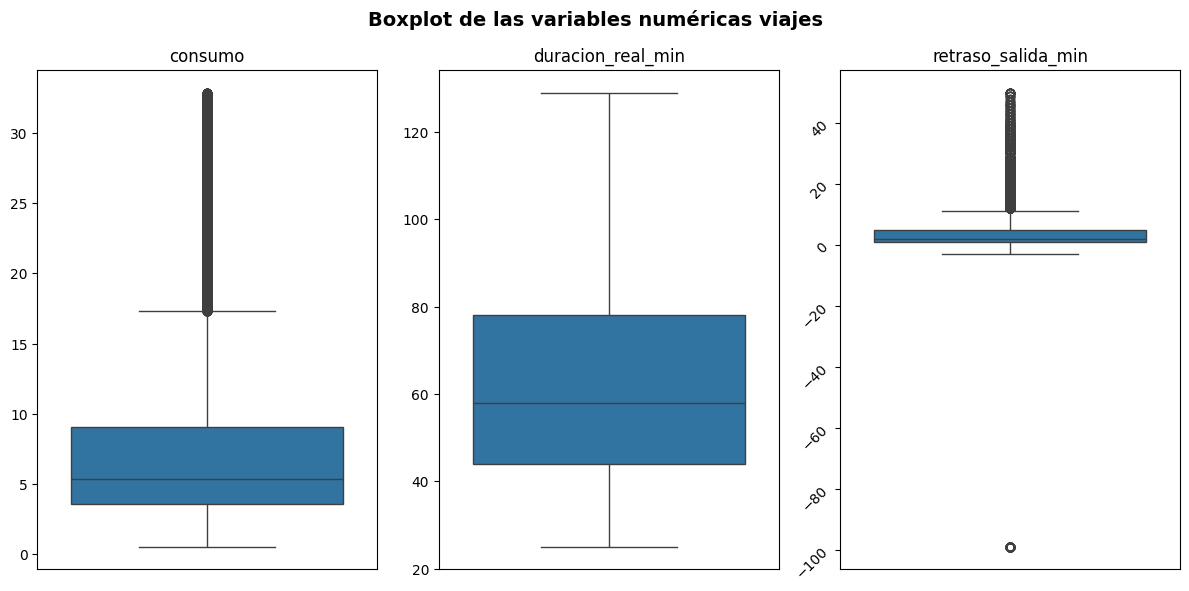

In [187]:
crear_boxplot_general(df_viajes[['consumo', 'duracion_real_min', 'retraso_salida_min']], "viajes")

Observando las diferentes gráficas, se puede apreciar que las variables **`retraso salida (min)`** y **`Consumo`** presentan valores atípicos (outliers). Por este motivo, se procederá a realizar un análisis individualizado de estas variables para determinar su origen y evaluar su impacto en el análisis de los datos.

#### **7.1.2.1 Consumo**

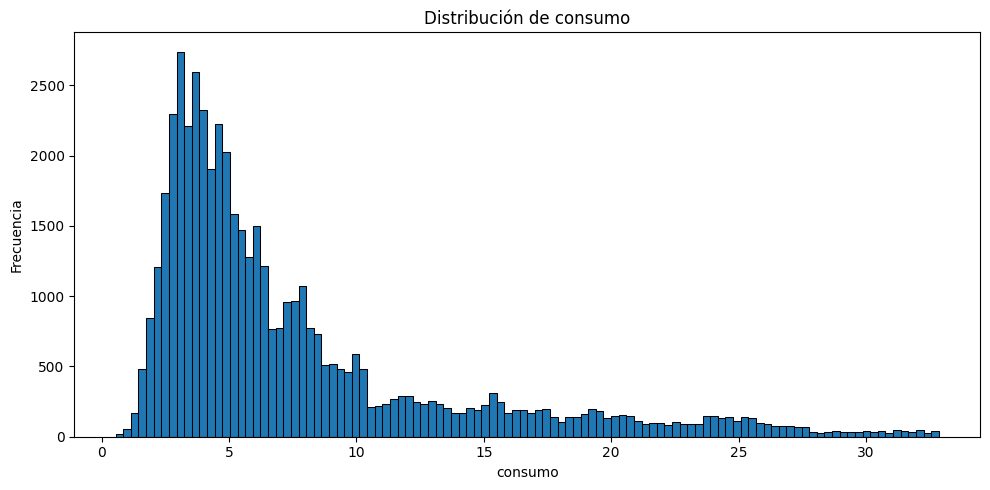

In [188]:
crear_histograma(df_viajes , "consumo")

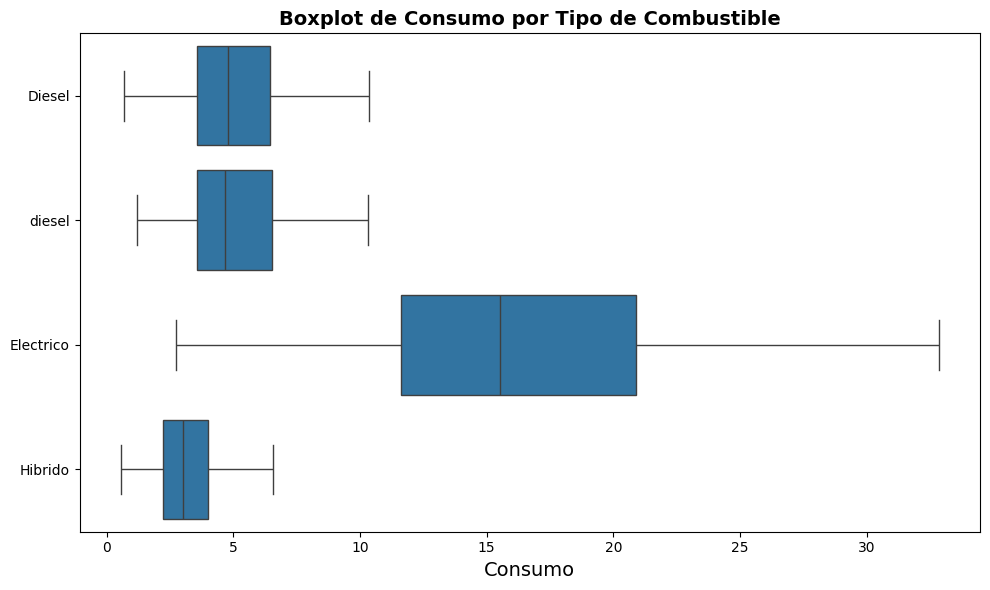

In [189]:
plt.figure(figsize=(10, 6))

sns.boxplot(

    data= pd.merge(df_viajes, df_vehiculos, "left","vehiculo_id"), 
    x="consumo", 
    y="combustible"
) 

plt.title(
    "Boxplot de Consumo por Tipo de Combustible",
    fontsize= 14,
    fontweight="bold"
)

plt.xlabel(
    "Consumo",
    fontsize= 14
)
plt.ylabel("")

plt.tight_layout()
plt.show()

**Conclusión — Consumo:**

Analizando el consumo por el tipo de combustible de cada vehiculo obtenemos un total de 0 valores atípicos.

#### **7.1.2.2 Retraso Salida Min**

In [190]:
df_retraso_sin_valores_invalidos = df_viajes[df_viajes["retraso_salida_min"] > df_viajes["retraso_salida_min"].min()]  # Excluidmos el valor -99

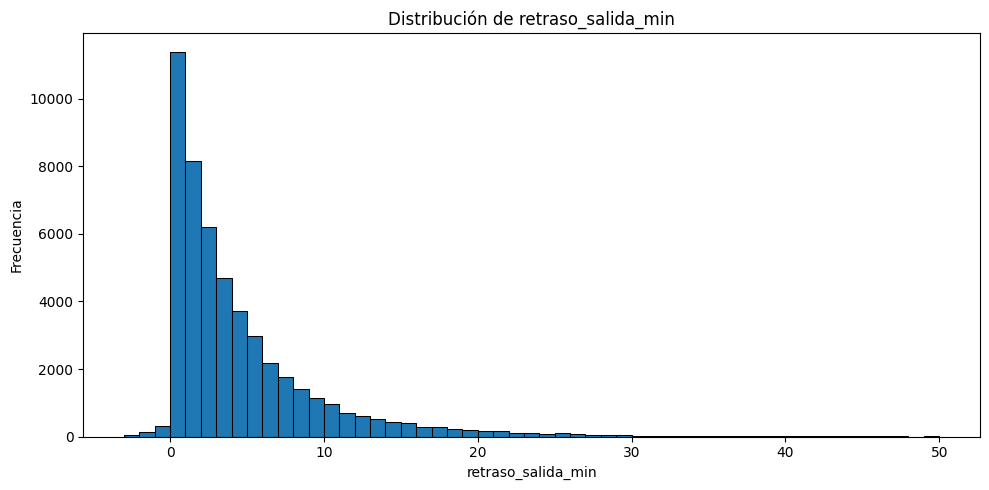

In [191]:
crear_histograma(df_retraso_sin_valores_invalidos, "retraso_salida_min")

Podemos apreciar una **distribucion no normal**, al tener un pico inicial muy marcado y progresivamente va disminuyendo, es por ello por lo que aplicaremos el método del **Rango Intercuartílico (IQR)**.

In [196]:
detectar_outliers_iqr(df_retraso_sin_valores_invalidos, "retraso_salida_min").unique()


Valores atípicos detectados con IQR: 4147


array([19, 13, 14, 18, 29, 24, 25, 17, 15, 32, 20, 12, 21, 27, 22, 16, 23,
       39, 28, 26, 41, 35, 46, 33, 50, 31, 34, 42, 30, 49, 38, 37, 43, 45,
       40, 36, 47, 44, 48])

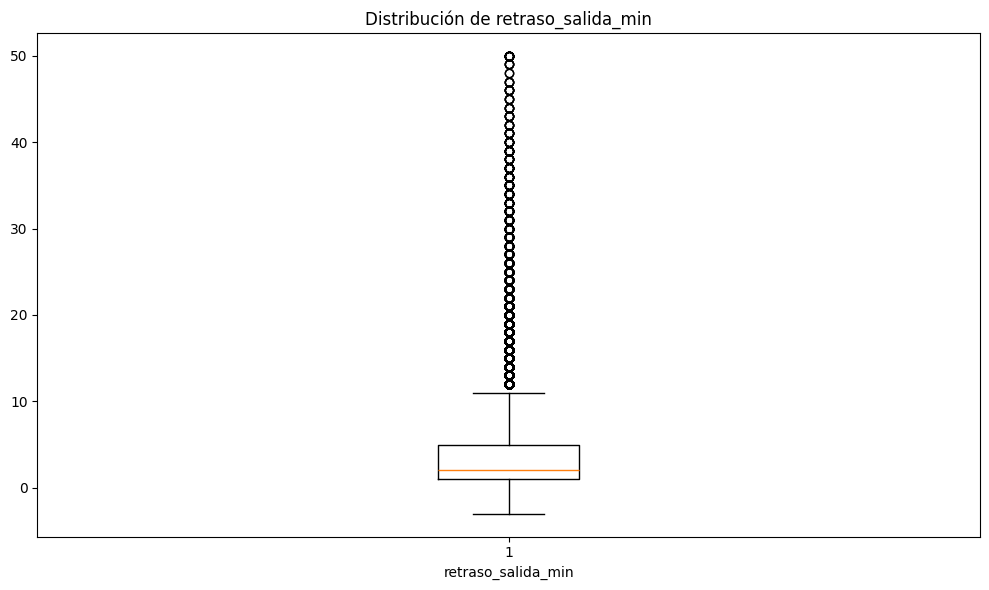

In [193]:
crear_boxplot(df_retraso_sin_valores_invalidos, "retraso_salida_min")

### **Conclusión — Retraso salida min:**

Se detectaron 4.147 valores atípicos mediante IQR (8,29 % del total), lo que equivale aproximadamente a 1 de cada 12 viajes. Dado el volumen detectado, es poco probable que se trate únicamente de errores de captura aislados, es posible que los datos reflejen retrasos reales del servicio.

**Decisión propuesta:** Mantener los valores sin eliminarlos, el volumen de retrasos atípicos podría no ser aleatorio, sino concentrarse en ciertas líneas, franjas horarias o conductores concretos.

## **7.2 Mantenimiento**

### **7.2.1 Analisis Inicial**

In [ ]:
df_mantenimientos.head(3)

In [ ]:
df_mantenimientos_metadatos = crear_tabla_metadatos(df_mantenimientos)
df_mantenimientos_metadatos

In [ ]:
df_mantenimientos.coste_eur[df_mantenimientos.coste_eur < 0.00].unique()

## **Hallazgos iniciales**

El análisis de los metadatos del DataFrame df_mantenimiento permite concluir que, en términos generales, la tabla presenta una calidad de datos aceptable. La mayoría de las variables contienen información completa y los valores registrados mantienen una estructura coherente. No obstante, se han identificado algunos aspectos que requieren una revisión más detallada durante las siguientes fases del EDA:

* Se ha detectado una discrepancia temporal en los datos, ya que la columna **anno** contiene registros correspondientes al año 2025, mientras que la información proporcionada indica que los archivos CSV representan datos históricos de MetroBus comprendidos entre los años 2022 y 2024.

*  La columna **coste_euros** presenta valores negativos, un comportamiento que no resulta coherente desde el punto de vista operativo.

* La columna **categoria** presenta 15 valores nulos, lo que representa aproximadamente un 1,71 % del total de registros.

Por ultimo, Las columnas relacionadas con **fechas** se encuentran almacenadas como tipo object, siendo el tipo de dato más adecuado para estas columnas datetime o time.

### **7.2.2 Outliers**

In [ ]:
crear_boxplot_general(df_mantenimientos[['coste_eur', 'km_en_revision', 'dias_fuera_servicio']], "mantenimiento")

Observando las diferentes gráficas, se puede apreciar que las variables **`Dias fuera de servicio`**, **`Coste euros`** y **`Garantia meses`** presentan valores atípicos (outliers). Por este motivo, se procederá a realizar un análisis individualizado de estas variables para determinar su origen y evaluar su impacto en el análisis de los datos.

#### **7.2.2.1 Dias fuera de servicio**

In [ ]:
crear_histograma(df_mantenimientos, "dias_fuera_servicio")

In [ ]:
calcular_iqr(df_mantenimientos, "dias_fuera_servicio")

In [ ]:
calcular_z_score(df_mantenimientos, "dias_fuera_servicio")

In [ ]:
crear_boxplot(df_mantenimientos, "dias_fuera_servicio")

#### **7.2.2.2 Coste euros**

In [ ]:
df_sin_valores_negativos = df_mantenimientos[ df_mantenimientos.coste_eur > 0] # Excluimos los valores negativos

In [ ]:
crear_histograma(df_sin_valores_negativos, "coste_eur")

In [ ]:
calcular_iqr(df_sin_valores_negativos, "coste_eur")

In [ ]:
crear_boxplot(df_sin_valores_negativos, "coste_eur")

#### **7.2.2.3 Garantia meses**

In [ ]:
crear_histograma(df_mantenimientos, "garantia_meses")

In [ ]:
calcular_iqr(df_mantenimientos, "garantia_meses")

In [ ]:
crear_boxplot(df_mantenimientos, "garantia_meses")

## **7.3 Incidencias**

### **7.3.1 Analisis Inicial**

In [ ]:
df_incidencias.head(3)

In [ ]:
df_incidencias_metadatos = crear_tabla_metadatos(df_incidencias)
df_incidencias_metadatos

In [ ]:
df_incidencias[df_incidencias.coste_estimado_eur == 0].head(3)

## **Hallazgos iniciales**

El análisis de los metadatos del DataFrame `df_incidencias` permite concluir que, en términos generales, la tabla presenta una calidad de datos aceptable. La mayoría de las variables contienen información completa y los valores registrados mantienen una estructura coherente. No obstante, se han identificado algunos aspectos que requieren una revisión más detallada durante las siguientes fases del EDA:

* La columna **coste_estimado_eur** presenta valores iguales a 0.00, un comportamiento que apriori no resulta coherente desde el punto de vista operativo.

* Las columnas relacionadas con **fechas** y **horas** se encuentran almacenadas como tipo object, siendo el tipo de dato más adecuado para estas columnas datetime o time.

### **7.3.2 Outliers**

In [ ]:
crear_boxplot_general(df_incidencias.select_dtypes(include="number"), 5, "incidencias")

Observando las diferentes gráficas, se puede apreciar que las variables **`Duracion Resolucion (min)`** y **`Coste Estimado euros`** presentan valores atípicos (outliers). Por este motivo, se procederá a realizar un análisis individualizado de estas variables para determinar su origen y evaluar su impacto en el análisis de los datos.

#### **7.3.2.1 Duracion resolucion (min)**

In [ ]:
crear_histograma(df_incidencias, "duracion_resolucion_min")

In [ ]:
calcular_z_score(df_incidencias, "duracion_resolucion_min")

In [ ]:
crear_boxplot(df_incidencias, "duracion_resolucion_min")

### **7.3.2.1 Coste estimado euros**

In [ ]:
crear_histograma(df_incidencias, "coste_estimado_eur")

In [ ]:
calcular_iqr(df_incidencias, "coste_estimado_eur")

In [ ]:
crear_boxplot(df_incidencias, "coste_estimado_eur")

## **7.4 Conductores**

### **7.4.1 Analisis Inicial**

In [ ]:
df_conductores.head(3)

In [ ]:
df_conductores_metadatos = crear_tabla_metadatos(df_conductores)
df_conductores_metadatos

In [ ]:
df_conductores['turno_habitual'].unique()

## **Hallazgos iniciales**

El análisis de los metadatos del DataFrame `df_conductores` permite concluir que, en términos generales, la tabla presenta una calidad de datos aceptable. La mayoría de las variables contienen información completa y los valores registrados mantienen una estructura coherente. No obstante, se han identificado algunos aspectos que requieren una revisión más detallada durante las siguientes fases del EDA:

* Se ha detectado una discrepancia temporal en los datos, ya que la columna **anno** contiene registros correspondientes al año 2025, mientras que la información proporcionada indica que los archivos CSV representan datos históricos de MetroBus comprendidos entre los años 2022 y 2024. 

* La variable **turno_habitual** presenta una inconsistencia en la codificación de categorías, ya que aparecen los valores Manana (06-14h) y manana, que representan el mismo turno.

### **7.4.2 Outliers**

In [ ]:
crear_boxplot_general(df_conductores.select_dtypes(include="number"), 5, "conductores")

Observando las diferentes gráficas, se puede apreciar que las variables **no presentan valores atípicos** (outliers). Por este motivo, no se procederá a realizar un análisis individualizado de estas variables.

## **7.5 Cocheras**

### **7.5.1 Analisis Inicial**

In [ ]:
df_cocheras.head(3)

In [ ]:
df_cocheras_metadatos = crear_tabla_metadatos(df_cocheras)
df_cocheras_metadatos

## **Hallazgos iniciales**

El análisis de los metadatos del DataFrame `df_cocheras` permite concluir que, en términos generales, la tabla presenta una calidad de datos aceptable. Todas las variables contienen información completa y los valores registrados mantienen una estructura coherente.

### **7.5.2 Outliers**

In [ ]:
crear_boxplot_general(df_cocheras.select_dtypes(include="number"), 4, "cocheras")

Observando las diferentes gráficas, se puede apreciar que las variables **no presentan valores atípicos** (outliers). Por este motivo, no se procederá a realizar un análisis individualizado de estas variables.

## **7.6 Lineas**

### **7.6.1 Analisis Inicial**

In [ ]:
df_lineas.head(10)

In [ ]:
df_lineas_metadatos = crear_tabla_metadatos(df_lineas)
df_lineas_metadatos

## **Hallazgos iniciales**

El análisis de los metadatos del DataFrame `df_lineas` permite concluir que, en términos generales, la tabla presenta una calidad de datos aceptable. Todas las variables contienen información completa y los valores registrados mantienen una estructura coherente.

### **7.6.2 Outliers**

In [ ]:
crear_boxplot_general(df_lineas.select_dtypes(include="number"), 4, "lineas")

Observando las diferentes gráficas, se puede apreciar que las variables **no presentan valores atípicos** (outliers). Por este motivo, no se procederá a realizar un análisis individualizado de estas variables.

## **7.7 Paradas**

### **7.7.1 Analisis Inicial**

In [ ]:
df_paradas.head(3)

In [ ]:
df_paradas_metadatos = crear_tabla_metadatos(df_paradas)
df_paradas_metadatos

In [ ]:
df_paradas.accesible_silla.unique()

In [ ]:
df_paradas.latitud.max()

In [ ]:
df_paradas.barrio.unique()

## **Hallazgos iniciales**

El análisis de los metadatos del DataFrame `df_paradas` permite concluir que, en términos generales, la tabla presenta una calidad de datos aceptable. La mayoría de las variables contienen información completa y los valores registrados mantienen una estructura coherente. No obstante, se han identificado algunos aspectos que requieren una revisión más detallada durante las siguientes fases del EDA:

* La columna **latitud** presenta 1 valor nulo (0,83 %). Del mismo modo, la columna **accesible_silla** también contiene 1 valor nulo (0,83 %).

* La variable **accesible_silla** está almacenada con tipo de dato object, aunque únicamente contiene valores booleanos (True y False). 

* La columna **latitud** presenta un valor máximo de 999.0, claramente fuera del rango válido para una coordenada geográfica. 

* La variable **barrio** presenta inconsistencias en la estandarización de sus valores, ya que existen registros que hacen referencia a una misma categoría pero aparecen representados de diferentes formas. Por ejemplo, valores como 'Barrio Norte' y 'BARRIO NORTE'.

### **7.7.2 Outliers**

In [ ]:
crear_boxplot_general(df_paradas.select_dtypes(include="number"), 3, "paradas")


Observando las diferentes gráficas, se puede apreciar que las variables **`Latitud`** y **`Longitud`** presentan valores atípicos (outliers). Respecto con el valor atipico de latitud sabemos por los hallazgos inicalies qeu corresponde al valor 999, asi pues no sera necesario un analisis del mismo. 

## **7.8 Tarifas**

### **7.8.1 Analisis Inicial**

In [ ]:
df_tarifas.head(9)

In [ ]:
df_tarifas_metadatos = crear_tabla_metadatos(df_tarifas)
df_tarifas_metadatos

In [ ]:
df_tarifas[df_tarifas['precio_eur'] == 0.0]

## **Hallazgos iniciales**

El análisis de los metadatos del DataFrame `df_tarifas` permite concluir que, en términos generales, la tabla presenta una calidad de datos aceptable. Todas las variables contienen información completa y los valores registrados mantienen una estructura coherente.

### **7.8.2 Outliers**

In [ ]:
crear_boxplot_general(df_tarifas.select_dtypes(include="number"), 2, "tarifas")

Observando las diferentes gráficas, se puede apreciar que la variables **`Precio euros`** presentan valores atípicos (outliers). 

#### **7.8.2.1 Precio euros**

In [ ]:
crear_histograma(df_tarifas, "precio_eur")

In [ ]:
calcular_iqr(df_tarifas, "precio_eur")

In [ ]:
crear_boxplot(df_tarifas, "precio_eur")

## **7.9 Vehiculos**

### **7.9.1 Analisis Inicial**

In [ ]:
df_vehiculos.head(3)

In [ ]:
df_vehiculos_metadatos = crear_tabla_metadatos(df_vehiculos)
df_vehiculos_metadatos

In [ ]:
df_vehiculos['anno_fabricacion'].unique()

In [ ]:
df_vehiculos['km_totales'].unique()

In [ ]:
df_vehiculos[df_vehiculos['emisiones_co2_gkm'] == 0]

In [ ]:
df_vehiculos['combustible'].unique()

## **Hallazgos iniciales**

El análisis de los metadatos del DataFrame `df_vehiculos` permite concluir que, en términos generales, la tabla presenta una calidad de datos aceptable. Todas las variables contienen información completa y los valores registrados mantienen una estructura coherente. La mayoría de las variables contienen información completa y los valores registrados mantienen una estructura coherente. No obstante, se han identificado algunos aspectos que requieren una revisión más detallada durante las siguientes fases del EDA:

* La columna **año_fabricacion** presenta un valor máximo de 2099, un dato claramente incoherente que deberá verificarse, ya que probablemente corresponda a un error de captura o de generación de los datos.

* La variable **km_totales** contiene un valor mínimo de -500 km, un registro imposible desde el punto de vista operativo.

* La columna **emisiones_co2_gkm** presenta valores iguales a 0 g/km. Tras revisar el conjunto de datos, se observa que estos registros corresponden a vehículos eléctricos.

* La variable **combustible** presenta una falta de estandarización en sus categorías, ya que aparecen los valores Diesel y diesel, que representan el mismo tipo de combustible.

### **7.9.2 Outliers**

In [ ]:
crear_boxplot_general(df_vehiculos.select_dtypes(include="number"), 4, "vehiculos")

Observando las diferentes gráficas, se puede apreciar que las variables **`Capacidad sentados`**, **`Capacidad total`** y **`Año fabricación`** presentan valores atípicos (outliers). Como pudimos comprobar en los hallazgos iniciales, el año de fabricacion es un error de insercion, ya que ese año corresponde a 2099. Por estos motivo, solo se procederá a realizar un análisis individualizado de **`Capacidad sentados`** y **`Capacidad total`** para determinar su origen y evaluar su impacto en el análisis de los datos.

#### **7.9.2.1 Capacidad sentados**

In [ ]:
crear_histograma(df_vehiculos, "capacidad_sentados")

In [ ]:
calcular_iqr(df_vehiculos, "capacidad_sentados")

In [ ]:
crear_boxplot(df_vehiculos, "capacidad_sentados")

#### **7.9.2.2 Capacidad total**

In [ ]:
crear_histograma(df_vehiculos, "capacidad_total")

In [ ]:
calcular_iqr(df_vehiculos, "capacidad_total")

In [ ]:
crear_boxplot(df_vehiculos, "capacidad_total")

## **8. Conclusión**